In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

df = pd.read_csv('zomato_dataset.csv')
print(df.shape)
print(df.head())


(44891, 7)
                       Restaurant Name Rating  \
0                        Campus Bakers    4.3   
1       Mama Chicken Mama Franky House      4   
2     GMB - Gopika Sweets & Restaurant    4.2   
3  Shree Bankey Bihari Misthan Bhandar    4.2   
4                          Burger King    4.2   

                                             Cuisine Average Price  \
0         Bakery, Fast Food, Pizza, Sandwich, Burger   ₹50 for one   
1        North Indian, Mughlai, Rolls, Burger, Momos   ₹50 for one   
2  North Indian, South Indian, Chinese, Fast Food...   ₹50 for one   
3  Mithai, Street Food, South Indian, Chinese, Ic...   ₹50 for one   
4                       Burger, Fast Food, Beverages   ₹50 for one   

  Average Delivery Time                                     Safety Measure  \
0                36 min            Restaurant partner follows WHO protocol   
1                22 min  Follows all Max Safety measures to ensure your...   
2                27 min  Follows all Ma

In [3]:
# Clean the delivery time column
df['Delivery_Time_Min'] = df['Average Delivery Time'].str.extract('(\d+)').astype(float)

# Clean the price column
df['Price'] = df['Average Price'].str.extract('(\d+)').astype(float)

# Drop rows with missing values
df = df.dropna(subset=['Delivery_Time_Min', 'Price', 'Rating', 'Location'])

# Check all unique cities
print(df.shape)
print(df['Location'].nunique(), "cities")
print(sorted(df['Location'].unique()))


<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_4896/1194349018.py:2: SyntaxWarning: invalid escape sequence '\d'
  df['Delivery_Time_Min'] = df['Average Delivery Time'].str.extract('(\d+)').astype(float)
/tmp/ipykernel_4896/1194349018.py:5: SyntaxWarning: invalid escape sequence '\d'
  df['Price'] = df['Average Price'].str.extract('(\d+)').astype(float)


(43307, 9)
98 cities
['Agra', 'Ahmedabad', 'Ajmer', 'Alappuzha', 'Aligarh', 'Allahabad', 'Amravati', 'Amritsar', 'Asansol', 'Aurangabad', 'Bangalore', 'Bareilly', 'Belgaum', 'Bhavnagar', 'Bhopal', 'Bhubaneswar', 'Bikaner', 'Chandigarh', 'Chennai', 'Coimbatore', 'Cuttack', 'Darbhanga', 'Darjeeling', 'Dehradun', 'Delhi NCR', 'Dhanbad', 'Dharamshala', 'Durgapur', 'Firozabad', 'Gaya', 'Goa', 'Gonda', 'Gorakhpur', 'Guntur', 'Guwahati', 'Haridwar', 'Hyderabad', 'Indore', 'Jabalpur', 'Jaipur', 'Jalandhar', 'Jalgaon', 'Jammu', 'Jamnagar', 'Jamshedpur', 'Jhansi', 'Jodhpur', 'Junagadh', 'Kanpur', 'Kharagpur', 'Kolhapur', 'Kolkata', 'Kota', 'Lucknow', 'Ludhiana', 'Madurai', 'Manali', 'Mangalore', 'Manipal', 'Meerut', 'Moradabad', 'Motihari', 'Mumbai', 'Mussoorie', 'Mysore', 'NCR', 'Nagpur', 'Nainital', 'Nashik', 'Nellore', 'Palakkad', 'Patiala', 'Patna', 'Puducherry', 'Pune', 'Raipur', 'Rajkot', 'Ranchi', 'Rishikesh', 'Saharanpur', 'Salem', 'Sangli', 'Shimla', 'Siliguri', 'Solapur', 'Surat', 'Thr

In [4]:
# Define Tier 2 cities to focus on
tier2_cities = ['Coimbatore', 'Indore', 'Jaipur', 'Bhubaneswar', 'Kochi',
                'Madurai', 'Trichy', 'Nashik', 'Vadodara', 'Visakhapatnam',
                'Surat', 'Nagpur', 'Lucknow', 'Patna', 'Ranchi']

# Filter only Tier 2 cities
df_tier2 = df[df['Location'].isin(tier2_cities)]

print("Total restaurants in Tier 2 cities:", len(df_tier2))
print("\nRestaurants per city:")
print(df_tier2['Location'].value_counts())

Total restaurants in Tier 2 cities: 8788

Restaurants per city:
Location
Lucknow          995
Indore           827
Surat            804
Jaipur           792
Coimbatore       759
Vadodara         744
Patna            742
Nagpur           732
Nashik           660
Bhubaneswar      550
Madurai          457
Trichy           303
Ranchi           252
Visakhapatnam    171
Name: count, dtype: int64


/tmp/ipykernel_4896/149024228.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=city_ratings, x='Location', y='Rating', palette='viridis')


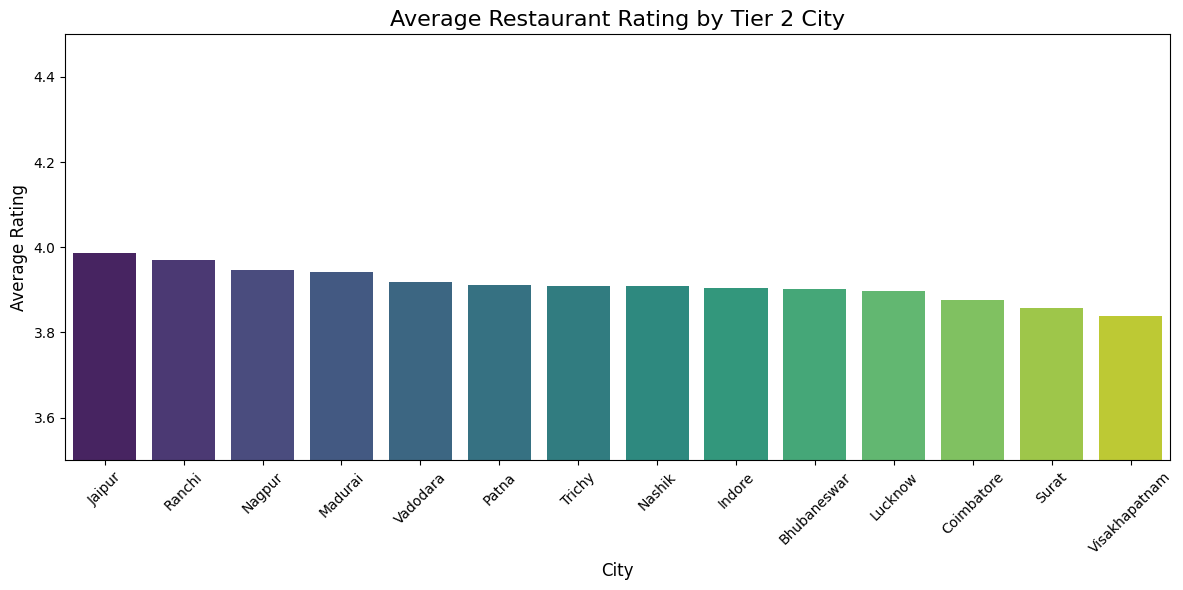

         Location    Rating
0          Jaipur  3.986229
1          Ranchi  3.970238
2          Nagpur  3.947230
3         Madurai  3.940988
4        Vadodara  3.919401
5           Patna  3.910840
6          Trichy  3.908696
7          Nashik  3.908031
8          Indore  3.905157
9     Bhubaneswar  3.901674
10        Lucknow  3.897651
11     Coimbatore  3.876043
12          Surat  3.857312
13  Visakhapatnam  3.838514


In [5]:
# Convert Rating to numeric
df_tier2 = df_tier2.copy()
df_tier2['Rating'] = pd.to_numeric(df_tier2['Rating'], errors='coerce')
df_tier2 = df_tier2.dropna(subset=['Rating'])

# Now plot
city_ratings = df_tier2.groupby('Location')['Rating'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=city_ratings, x='Location', y='Rating', palette='viridis')
plt.title('Average Restaurant Rating by Tier 2 City', fontsize=16)
plt.xlabel('City', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(3.5, 4.5)
plt.tight_layout()
plt.savefig('chart1_ratings_by_city.png', dpi=150)
plt.show()

print(city_ratings)

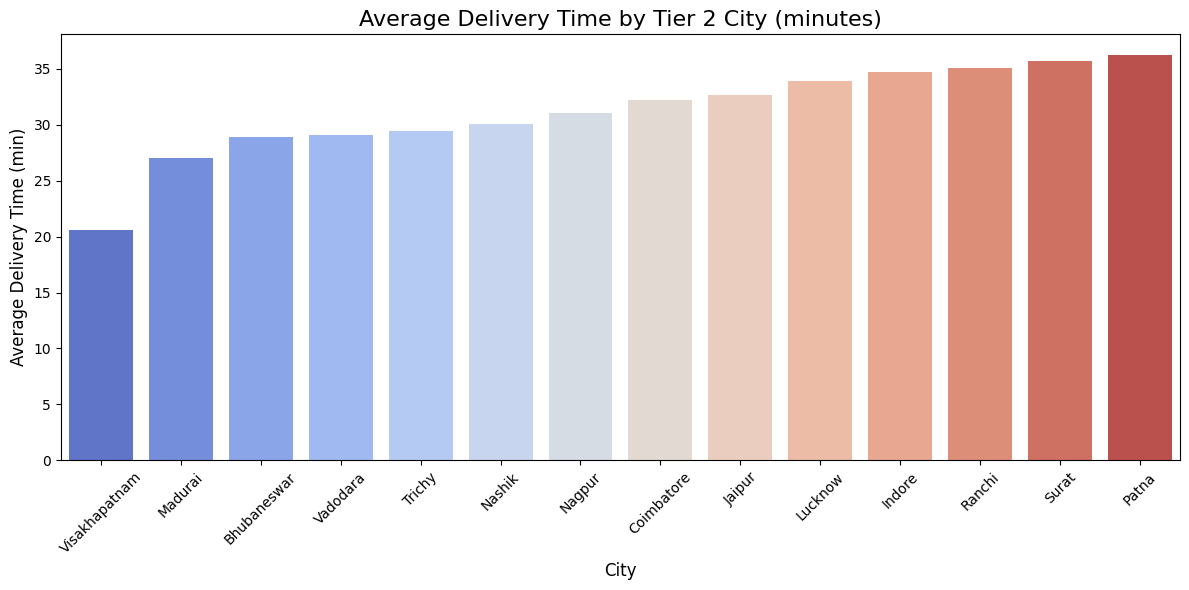

         Location  Delivery_Time_Min
0   Visakhapatnam          20.587838
1         Madurai          27.076543
2     Bhubaneswar          28.876569
3        Vadodara          29.092725
4          Trichy          29.442688
5          Nashik          30.110899
6          Nagpur          31.073407
7      Coimbatore          32.199382
8          Jaipur          32.711712
9         Lucknow          33.957099
10         Indore          34.763522
11         Ranchi          35.071429
12          Surat          35.678524
13          Patna          36.280916


In [6]:
# Average delivery time per city
city_delivery = df_tier2.groupby('Location')['Delivery_Time_Min'].mean().sort_values().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=city_delivery, x='Location', y='Delivery_Time_Min',
            hue='Location', palette='coolwarm', legend=False)
plt.title('Average Delivery Time by Tier 2 City (minutes)', fontsize=16)
plt.xlabel('City', fontsize=12)
plt.ylabel('Average Delivery Time (min)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart2_delivery_time.png', dpi=150)
plt.show()

print(city_delivery)

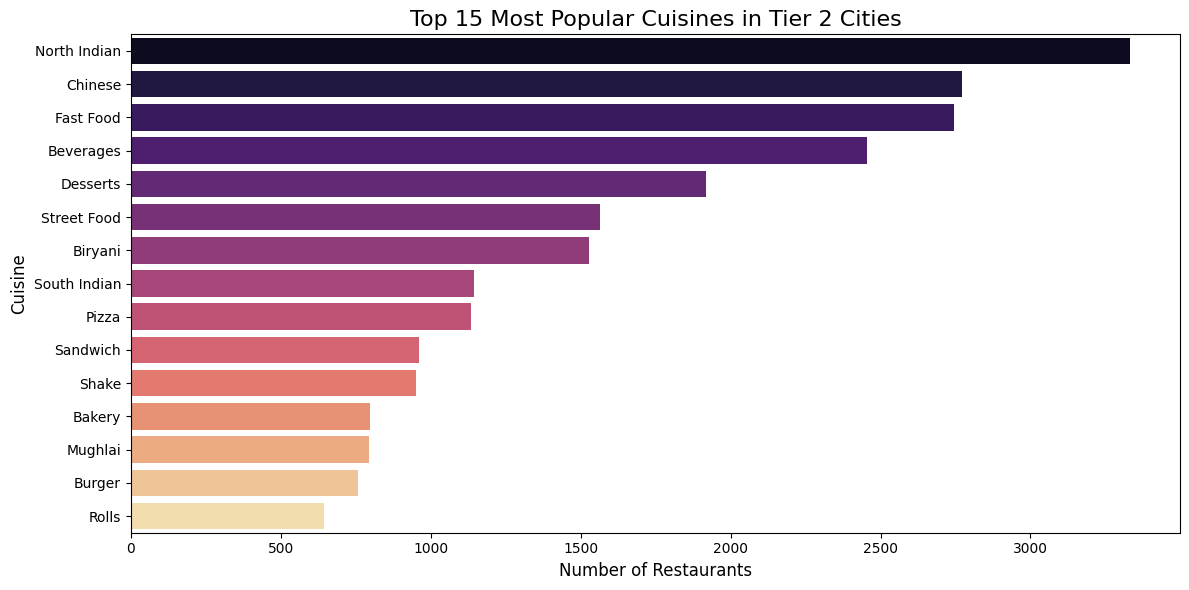

         Cuisine  Count
0   North Indian   3332
1        Chinese   2771
2      Fast Food   2744
3      Beverages   2455
4       Desserts   1918
5    Street Food   1566
6        Biryani   1527
7   South Indian   1143
8          Pizza   1134
9       Sandwich    960
10         Shake    952
11        Bakery    798
12       Mughlai    793
13        Burger    756
14         Rolls    645


In [7]:

# Most popular cuisines in Tier 2 cities
from collections import Counter

all_cuisines = []
for cuisines in df_tier2['Cuisine'].dropna():
    for cuisine in cuisines.split(','):
        all_cuisines.append(cuisine.strip())

cuisine_counts = Counter(all_cuisines)
top_cuisines = pd.DataFrame(cuisine_counts.most_common(15),
                             columns=['Cuisine', 'Count'])

plt.figure(figsize=(12, 6))
sns.barplot(data=top_cuisines, x='Count', y='Cuisine',
            hue='Cuisine', palette='magma', legend=False)
plt.title('Top 15 Most Popular Cuisines in Tier 2 Cities', fontsize=16)
plt.xlabel('Number of Restaurants', fontsize=12)
plt.ylabel('Cuisine', fontsize=12)
plt.tight_layout()
plt.savefig('chart3_top_cuisines.png', dpi=150)
plt.show()

print(top_cuisines)

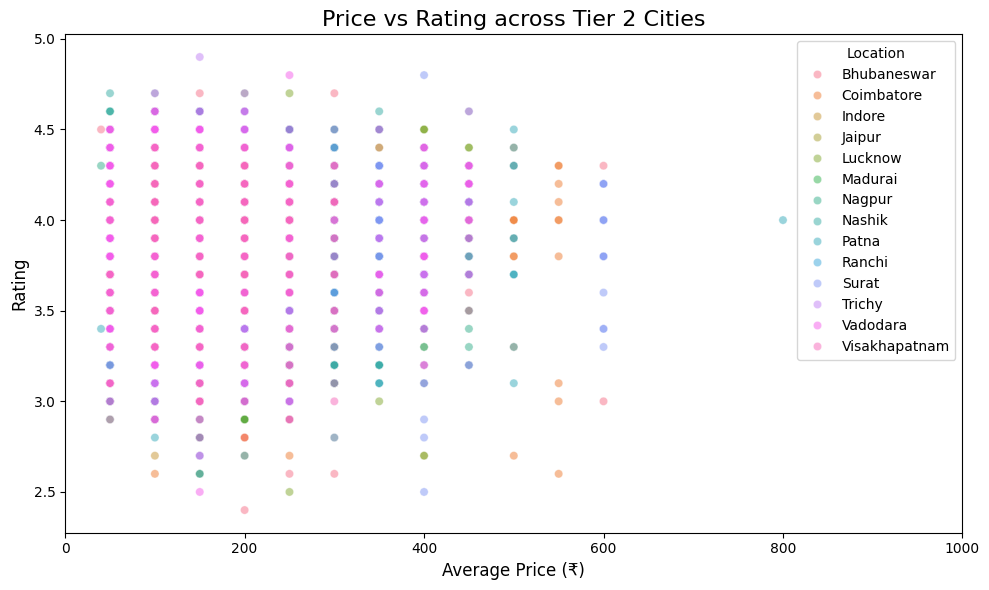

Correlation between Price and Rating: -0.01


In [8]:
# Price vs Rating analysis - are expensive restaurants better rated?
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_tier2, x='Price', y='Rating',
                hue='Location', alpha=0.5)
plt.title('Price vs Rating across Tier 2 Cities', fontsize=16)
plt.xlabel('Average Price (₹)', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.xlim(0, 1000)
plt.tight_layout()
plt.savefig('chart4_price_vs_rating.png', dpi=150)
plt.show()

# Correlation between price and rating
correlation = df_tier2['Price'].corr(df_tier2['Rating'])
print(f"Correlation between Price and Rating: {correlation:.2f}")

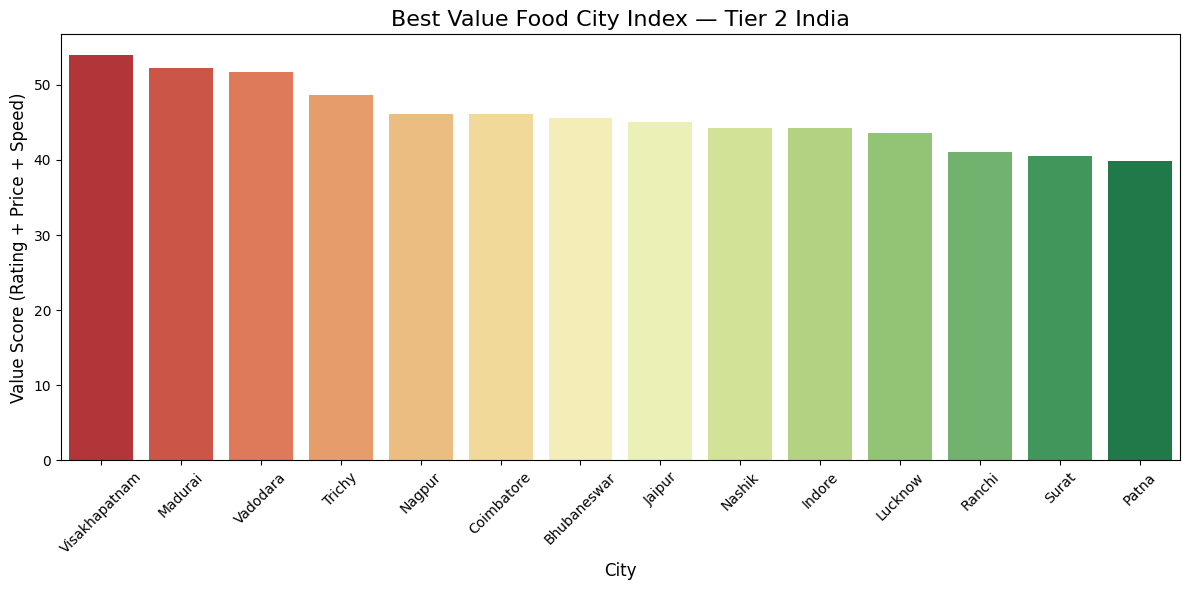

         Location  Value_Score  Avg_Rating   Avg_Price  Avg_Delivery
13  Visakhapatnam    54.028855    3.838514  173.648649     20.587838
5         Madurai    52.182444    3.940988  157.901235     27.076543
12       Vadodara    51.728892    3.919401  148.858773     29.092725
11         Trichy    48.619694    3.908696  166.007905     29.442688
6          Nagpur    46.139331    3.947230  175.609418     31.073407
1      Coimbatore    46.087662    3.876043  165.533230     32.199382
0     Bhubaneswar    45.629621    3.901674  187.426778     28.876569
3          Jaipur    45.012838    3.986229  176.640927     32.711712
7          Nashik    44.317184    3.908031  189.674952     30.110899
2          Indore    44.209615    3.905157  165.849057     34.763522
4         Lucknow    43.551653    3.897651  173.748723     33.957099
9          Ranchi    41.089496    3.970238  188.095238     35.071429
10          Surat    40.478411    3.857312  181.620553     35.678524
8           Patna    39.918926    

In [9]:
# Best value cities - high rating, low price, fast delivery
city_summary = df_tier2.groupby('Location').agg(
    Avg_Rating=('Rating', 'mean'),
    Avg_Price=('Price', 'mean'),
    Avg_Delivery=('Delivery_Time_Min', 'mean'),
    Restaurant_Count=('Restaurant Name', 'count')
).reset_index()

# Create a value score - high rating, low price, fast delivery
city_summary['Value_Score'] = (
    (city_summary['Avg_Rating'] / city_summary['Avg_Rating'].max()) * 40 +
    (1 - city_summary['Avg_Price'] / city_summary['Avg_Price'].max()) * 30 +
    (1 - city_summary['Avg_Delivery'] / city_summary['Avg_Delivery'].max()) * 30
)

city_summary = city_summary.sort_values('Value_Score', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=city_summary, x='Location', y='Value_Score',
            hue='Location', palette='RdYlGn', legend=False)
plt.title('Best Value Food City Index — Tier 2 India', fontsize=16)
plt.xlabel('City', fontsize=12)
plt.ylabel('Value Score (Rating + Price + Speed)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart5_value_index.png', dpi=150)
plt.show()

print(city_summary[['Location', 'Value_Score', 'Avg_Rating', 'Avg_Price', 'Avg_Delivery']])



In [10]:
# Install plotly
!pip install plotly -q

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [11]:
# Interactive Value Score Chart
fig = px.bar(
    city_summary.sort_values('Value_Score', ascending=False),
    x='Location',
    y='Value_Score',
    color='Value_Score',
    color_continuous_scale='RdYlGn',
    title='Best Value Food City Index — Tier 2 India',
    labels={'Value_Score': 'Value Score', 'Location': 'City'},
    hover_data=['Avg_Rating', 'Avg_Price', 'Avg_Delivery']
)
fig.update_layout(height=500)
fig.show()

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from collections import Counter
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

# Load data
df = pd.read_csv('zomato_dataset.csv')

# Clean columns
df['Delivery_Time_Min'] = df['Average Delivery Time'].str.extract(r'(\d+)').astype(float)
df['Price'] = df['Average Price'].str.extract(r'(\d+)').astype(float)
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df = df.dropna(subset=['Delivery_Time_Min', 'Price', 'Rating', 'Location'])

# Filter Tier 2 cities
tier2_cities = ['Coimbatore', 'Indore', 'Jaipur', 'Bhubaneswar',
                'Madurai', 'Trichy', 'Nashik', 'Vadodara', 'Visakhapatnam',
                'Surat', 'Nagpur', 'Lucknow', 'Patna', 'Ranchi']

df_tier2 = df[df['Location'].isin(tier2_cities)].copy()

# Feature engineering
df_tier2['City_Encoded'] = LabelEncoder().fit_transform(df_tier2['Location'])
df_tier2['Cuisine_Count'] = df_tier2['Cuisine'].apply(
    lambda x: len(str(x).split(',')) if pd.notna(x) else 0)
df_tier2['Price_Category'] = pd.cut(df_tier2['Price'],
    bins=[0, 100, 200, 300, 500, 2000],
    labels=['Budget', 'Affordable', 'Moderate', 'Premium', 'Luxury'])
df_tier2['Price_Cat_Encoded'] = LabelEncoder().fit_transform(
    df_tier2['Price_Category'].astype(str))
df_tier2['Success'] = (df_tier2['Rating'] >= 4.0).astype(int)

print("Data ready:", df_tier2.shape)
print("Cities:", df_tier2['Location'].nunique())

# ML Model
df_ml = df_tier2[['Price', 'Delivery_Time_Min', 'City_Encoded',
                   'Cuisine_Count', 'Price_Cat_Encoded', 'Success']].dropna()

X = df_ml[['Price', 'Delivery_Time_Min', 'City_Encoded',
            'Cuisine_Count', 'Price_Cat_Encoded']]
y = df_ml['Success']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42)
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print(f"\nModel Accuracy: {accuracy:.2%}")
print(classification_report(y_test, model.predict(X_test)))

# Feature importance chart
importance_df = pd.DataFrame({
    'Feature': ['Price', 'Delivery Time', 'City',
                'Cuisine Variety', 'Price Category'],
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

fig = px.bar(importance_df, x='Importance', y='Feature',
             orientation='h',
             title='What Actually Predicts Restaurant Success in Tier 2 India?',
             color='Importance', color_continuous_scale='viridis')
fig.update_layout(height=400)
fig.show()

print("\nStrongest predictor:", importance_df.iloc[0]['Feature'])

Data ready: (8094, 14)
Cities: 14

Model Accuracy: 57.38%
              precision    recall  f1-score   support

           0       0.54      0.41      0.47       735
           1       0.59      0.71      0.65       884

    accuracy                           0.57      1619
   macro avg       0.57      0.56      0.56      1619
weighted avg       0.57      0.57      0.56      1619




Strongest predictor: Delivery Time


In [14]:
# Cuisine Gap Analysis - where is demand vs supply mismatched?
south_indian_by_city = df_tier2[
    df_tier2['Cuisine'].str.contains('South Indian', na=False)
].groupby('Location').size().reset_index(name='South_Indian_Count')

total_by_city = df_tier2.groupby('Location').size().reset_index(name='Total')

gap_df = pd.merge(total_by_city, south_indian_by_city, on='Location')
gap_df['South_Indian_Percentage'] = (
    gap_df['South_Indian_Count'] / gap_df['Total'] * 100).round(2)

gap_df = gap_df.sort_values('South_Indian_Percentage')

fig = px.bar(gap_df, x='Location', y='South_Indian_Percentage',
             title='South Indian Cuisine Representation by City (%)',
             color='South_Indian_Percentage',
             color_continuous_scale='RdYlGn',
             labels={'South_Indian_Percentage': '% of Restaurants'})
fig.update_layout(height=450)
fig.show()

print("\nCities with lowest South Indian representation:")
print(gap_df[['Location', 'South_Indian_Percentage']].head(5))
print("\nBusiness Insight: These cities have highest opportunity")
print("for new South Indian restaurant entrants on Zomato")


Cities with lowest South Indian representation:
       Location  South_Indian_Percentage
12     Vadodara                     6.28
6        Nagpur                     9.14
2        Indore                     9.18
0   Bhubaneswar                     9.41
10        Surat                     9.49

Business Insight: These cities have highest opportunity
for new South Indian restaurant entrants on Zomato


In [16]:
# Final Business Recommendations
recommendations = {
    'Finding': [
        'Best Value City',
        'Highest Rated City',
        'Fastest Delivery City',
        'Biggest Cuisine Gap',
        'Price vs Quality',
        'ML Model Insight'
    ],
    'Result': [
        'Visakhapatnam — best combo of price, rating and speed',
        'Jaipur — highest average restaurant rating (3.99)',
        'Visakhapatnam — average 20.6 minutes delivery',
        'Vadodara — only 6.28% South Indian restaurants',
        'Near zero correlation (0.01) — cheap food rates as well as expensive',
        '57% accuracy — success driven by quality not operations'
    ],
    'Business Action': [
        'Zomato should prioritise Visakhapatnam for premium partnerships',
        'Jaipur restaurants should be featured in quality campaigns',
        'Benchmark Visakhapatnam delivery ops across all Tier 2 cities',
        'South Indian chains should expand to Vadodara and Nagpur first',
        'New restaurants need not invest heavily in premium pricing',
        'Focus on food quality metrics over delivery speed for ratings'
    ]
}

rec_df = pd.DataFrame(recommendations)

fig = go.Figure(data=[go.Table(
    columnwidth=[200, 350, 350],
    header=dict(
        values=['Finding', 'Result', 'Business Action'],
        fill_color='#2E86AB',
        font=dict(color='white', size=13),
        align='left',
        height=40
    ),
    cells=dict(
        values=[rec_df['Finding'], rec_df['Result'], rec_df['Business Action']],
        fill_color=[['#f8f9fa', '#ffffff']*3],
        align='left',
        height=60,
        font=dict(size=12)
    )
)])

fig.update_layout(
    title='Business Recommendations — Tier 2 India Food Delivery Analysis',
    height=500
)
fig.show()